# Employing Deep Learning to Predict Parkinson’s Disease using

Microbiome Data

Longhai Li  
2026-07-07

## Welcome to the Project!

Here’s your mission for the summer: teach a computer to look at the
bacteria living inside someone’s gut and guess whether that person has
Parkinson’s Disease (PD). No blood test, no brain scan — just bacteria.

Sounds like science fiction? It’s real, cutting-edge research, and by
the end of this project *you will have built it yourself.*

Never touched biology or code before? Perfect — that’s exactly who this
guide is written for. We’ll take the science, the data, the programming,
and the final write-up one bite at a time, and you’ll be surprised how
far you get.

This is the init_notebook_mode cell from ITables v2.8.1 
(you should not see this message - is your notebook trusted ?)

------------------------------------------------------------------------

## 📥 Access this Document Interactive Notebook

You can download the raw code for this project or run it directly in
your browser using Google Colab.

<figure>
<a
href="https://colab.research.google.com/github/longhaiSK/PDNN/blob/main/index.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

[Download the .ipynb File](index.ipynb)

## The Biology: What is the Microbiome and Parkinson’s Disease?

Picture your gut as a crowded, buzzing city. The “citizens” are
*trillions* of tiny microorganisms — mostly bacteria — all living,
eating, and elbowing each other for space inside you right now.
Scientists call this hidden community your **gut microbiome**.

In a healthy person, the microbial city runs in balance: lots of
different bacterial families, all keeping one another in check. But in
people with **Parkinson’s Disease**, the population of the gut city
shifts. Some “good” families crash. Others explode. The whole
neighborhood gets rearranged (Scheperjans et al. 2015).

Here’s the wild part, and the reason this project even exists: **your
gut and your brain are constantly talking to each other.** They’re wired
together through nerves (especially one long one called the *vagus
nerve*), plus a stream of chemical and immune signals. Scientists call
this two-way phone line the **gut–brain axis**. In Parkinson’s, many
researchers now suspect the trouble may actually *start down in the gut,
years before* the brain symptoms ever appear. That’s why the bacteria in
someone’s stomach can act like an early-warning signal for a *brain*
disease — and it’s what makes your prediction model possible.

<figure id="fig-gutbrain">
<img
src="https://commons.wikimedia.org/wiki/Special:FilePath/Gut-brain_axis_overview.jpg" />
<figcaption>Figure 1: The <strong>gut–brain axis</strong>: signals
travel in both directions between the trillions of microbes in your gut
and your brain, partly along the vagus nerve. In Parkinson’s disease,
this two-way connection appears to get disrupted — sometimes starting in
the gut long before the brain. <em>(Image: Wikimedia Commons, CC BY 4.0.
Feel free to swap in your own favorite diagram.)</em></figcaption>
</figure>

### Four clues that flipped the script

For a long time, Parkinson’s was seen as a purely *brain* disease. Then
a handful of strange discoveries dragged the spotlight down to the gut.
Here are four of them.

**1. The warning comes from the wrong end.** Long before the first
tremor, most people with Parkinson’s have stubborn **constipation** — it
shows up in the large majority of patients (Fasano et al. 2015), and
often appears *many years, sometimes more than a decade,* ahead of any
movement problems. In one long-running study, men with the least
frequent bowel movements went on to develop Parkinson’s at several times
the rate of others, sometimes a decade or more later (Abbott et al.
2001). A brain disease announcing itself through the digestive system
was one of the first big hints that the story starts somewhere
unexpected.

**2. Swap the bacteria, swap the symptoms.** In a now-famous experiment,
scientists bred mice genetically rigged to develop Parkinson’s-like
problems. One group grew up with normal gut bacteria; the other was
raised *completely germ-free*. The germ-free mice stayed remarkably
healthy — same faulty genes, but almost no symptoms. Then the
researchers took gut bacteria from *human* Parkinson’s patients and
transferred them into the mice… and the symptoms came roaring back.
Bacteria from healthy people did nothing (Sampson et al. 2016). The bugs
weren’t just *along for the ride* — in mice, at least, they seemed to be
*driving*.

**3. Cutting the phone line.** Remember the vagus nerve, the gut–brain
“phone line”? Decades ago, surgeons sometimes cut it to treat stomach
ulcers. When scientists went back and checked those patients years
later, some found they were *less* likely to develop Parkinson’s — as if
snipping the wire had blocked a message from reaching the brain
(Svensson et al. 2015). (Not every study agrees, and researchers are
still arguing about it (Liu et al. 2017) — which is exactly how real
science works.)

**4. The bugs even eat the medicine.** The main drug for Parkinson’s,
*levodopa*, has to travel through the gut to reach the brain. But
certain gut bacteria grab it and break it down *first* — like a package
thief on the porch. That means two patients on the exact same dose can
get very different results, depending on who’s living in their gut
(Maini Rekdal et al. 2019).

Tying the thread together: many scientists think a misshapen protein
called **alpha-synuclein** is the “bad message” itself. It can misfold
down in the gut, clump together, and spread *upward* along the vagus
nerve in a chain reaction, seeding the same damage in the brain (Braak
et al. 2003). If that idea is right, the gut isn’t just a *mirror* of
the disease — it might be where the disease is *born*. This is still a
leading hypothesis, not settled fact, and testing it is one of the
hottest questions in the field.

So how do scientists actually *see* these bacteria? They can’t line them
up and count them by hand. Instead, they take a stool sample and
sequence the DNA inside it — basically running a **census** of the gut
city. What comes back is a giant spreadsheet:

- Every **row** is a different patient.
- Every **column** is a different type of bacteria.
- Each **number** is how many of that specific bacteria showed up in
  that patient’s gut.

Reading this “census” isn’t just a biological curiosity. It’s a race to
catch the disease at its roots, years before the brain is permanently
damaged. Your job is to find the hidden pattern buried in that
spreadsheet — the one no human eye can catch, but a machine can.

------------------------------------------------------------------------

## The Data: From Messy Counts to Hidden Patterns

Here’s a catch nobody warns you about. When that DNA sequencer runs its
census, it doesn’t count *every* bacterium — that would be impossible.
It grabs a random scoop and counts what’s in the scoop. The total number
of bacteria it manages to count in one sample is called the **Total
Reads**.

And the scoop is never the same size twice. The machine might catch
40,000 bacteria in Patient 1’s sample but only 15,000 in Patient 8’s —
same gut, wildly different totals, purely because of how much got
scooped.

This messiness is the first real boss you’ll have to beat. Let’s build a
fake-but-realistic dataset of 100 patients (50 with Parkinson’s, 50
healthy) and watch the problem show up with our own eyes. To keep things
readable, we’ll track just **6 bacterial families**.

### Step 1: A Synthesized Raw Data

First, let’s generate the raw counts — the messy numbers straight off
the machine, before anyone cleans them up.

**Data Generating Function**

In [2]:
import numpy as np
import pandas as pd

# Reusable Data Generating Process (DGP)
def generate_microbiome_data(n_pd=50, n_healthy=50, seed=42):
    np.random.seed(seed)
    
    # 1. Generate Total Reads (The Scoop Size - just for realism)
    total_reads = np.concatenate([
        np.random.normal(40000, 5000, n_pd).astype(int),
        np.random.normal(15000, 3000, n_healthy).astype(int)
    ])
    
    # 2. Pair 1: The Hidden Biological Signal (Bifido & Lacto)
    # Bifido has the EXACT same distribution (0.02 - 0.13) in both groups now!
    bifido_pd = np.random.uniform(0.01, 0.05, n_pd)
    lacto_pd = 0.1 - bifido_pd + np.random.normal(0, 0.05, n_pd) 
    
    bifido_healthy = np.random.uniform(0.01, 0.05, n_pd)
    lacto_healthy = 0.2 - bifido_healthy + np.random.normal(0, 0.05, n_healthy)
    
    # 3. Pair 3: Independent Noise (Esch & Kleb)
    # Generated with a constant sum (0.20) for BOTH groups so they are totally uninformative
    esch_pd = np.random.uniform(0.05, 0.1, n_pd)
    kleb_pd = 0.20 - esch_pd + np.random.normal(0, 0.05, n_pd)
    
    esch_healthy = np.random.uniform(0.05, 0.1, n_pd)
    kleb_healthy = 0.15 - esch_healthy + np.random.normal(0, 0.05, n_healthy)
    
    # 4. Pair 2: The Compositional Trap (Bact & Prev)
    bact_pd = np.random.uniform(0.10, 0.30, n_pd)
    prev_pd = 1.0 - (bifido_pd + lacto_pd + esch_pd + kleb_pd + bact_pd)
    # Truncate below at 0 to prevent negative relative abundances
    prev_pd = np.maximum(prev_pd, 0.0)

    bact_healthy = np.random.uniform(0.10, 0.30, n_healthy)
    prev_healthy = 1.0 - (bifido_healthy + lacto_healthy + esch_healthy + kleb_healthy + bact_healthy)
    # Truncate below at 0 to prevent negative relative abundances
    prev_healthy = np.maximum(prev_healthy, 0.0)
    
    # 5. Assemble into a unified matrix
    bacteria_cols = ["Bifidobacterium", "Lactobacillus", "Bacteroides", "Prevotella", "Escherichia", "Klebsiella"]
    proportions = np.column_stack([
        np.concatenate([bifido_pd, bifido_healthy]),
        np.concatenate([lacto_pd, lacto_healthy]),
        np.concatenate([bact_pd, bact_healthy]),
        np.concatenate([prev_pd, prev_healthy]),
        np.concatenate([esch_pd, esch_healthy]),
        np.concatenate([kleb_pd, kleb_healthy])
    ])
    
    df = pd.DataFrame(proportions, columns=bacteria_cols)
    df["Diagnosis"] = ["Parkinson's"] * n_pd + ["Healthy"] * n_healthy
    
    # Extract Features (X) and Target (y)
    X = df[bacteria_cols].values
    y = (df["Diagnosis"] == "Parkinson's").astype(int).values
    
    return X, y

In [3]:
from itables import show, init_notebook_mode
import pandas as pd
import numpy as np
init_notebook_mode(all_interactive=True)

# 1. Use the DGP to generate the core proportions and diagnosis labels
X_data, y_data = generate_microbiome_data(n_pd=50, n_healthy=50, seed=42)

# 2. Re-create the metadata (Total_Reads and Patient IDs)
reads_pd = np.random.normal(40000, 5000, 50).astype(int)
reads_healthy = np.random.normal(15000, 3000, 50).astype(int)
total_reads = np.concatenate([reads_pd, reads_healthy])

# 3. Assemble into the final DataFrame
bacteria_cols = ["Bifidobacterium", "Lactobacillus", "Bacteroides", "Prevotella", "Escherichia", "Klebsiella"]
df_raw = pd.DataFrame(X_data, columns=bacteria_cols)

# Add metadata
df_raw["Patient_ID"] = [f"PD_{str(i).zfill(3)}" for i in range(1, 51)] + [f"Healthy_{str(i).zfill(3)}" for i in range(1, 51)]
df_raw["Diagnosis"] = ["Parkinson's"] * 50 + ["Healthy"] * 50
df_raw["Total_Reads"] = total_reads

# Convert proportions back to raw counts
for col in bacteria_cols:
    df_raw[col] = (df_raw[col] * df_raw["Total_Reads"]).astype(int)

# Reorder columns
df_raw = df_raw[["Patient_ID", "Diagnosis", "Total_Reads"] + bacteria_cols]

# 4. Display the table with strict container limits
show(
    df_raw, 
    classes="display compact nowrap", 
    scrollX=True,
    autoWidth=False,
    lengthMenu=[10, 20], 
    style="width: 100%; table-layout: fixed; font-size: 0.8rem;"
)

This is the init_notebook_mode cell from ITables v2.8.1 
(you should not see this message - is your notebook trusted ?)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


If you hand these raw numbers straight to a computer, it’ll be fooled —
and honestly, so would you. In our data, the Parkinson’s samples just
happened to get scooped more deeply (bigger Total Reads), so *every
single* bacteria count looks sky-high for them. It’s a trap: the numbers
look different, but only because of scoop size, not biology.

Let’s prove it with a **boxplot**. Quick decoder: the box holds the
middle chunk of patients, the line inside is the typical value, and the
whiskers stretch out toward the extremes.

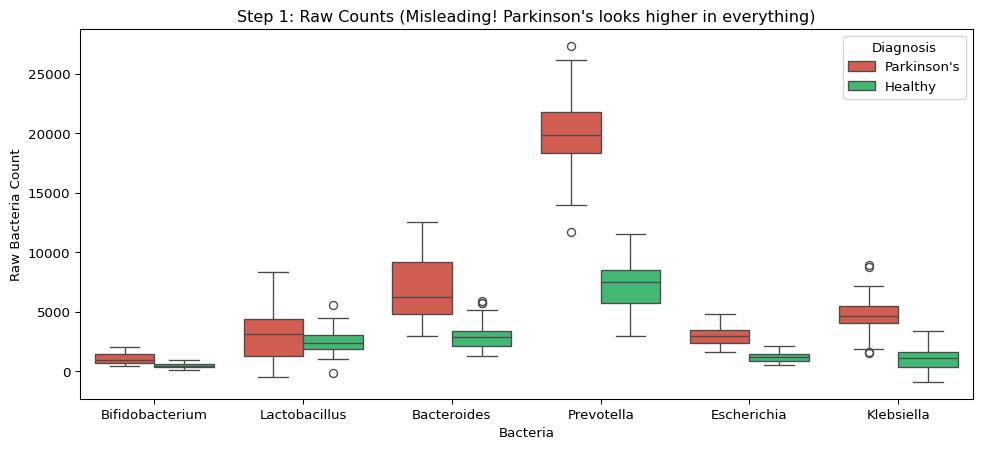

In [4]:
# Reshape the data for seaborn plotting
cols = ["Bifidobacterium", "Lactobacillus", "Bacteroides", "Prevotella", "Escherichia", "Klebsiella"]
df_raw_melted = df_raw.melt(id_vars=["Diagnosis"], value_vars=cols, var_name="Bacteria", value_name="Raw_Count")

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_raw_melted, x="Bacteria", y="Raw_Count", hue="Diagnosis", palette=["#e74c3c", "#2ecc71"])
plt.title("Step 1: Raw Counts (Misleading! Parkinson's looks higher in everything)")
plt.ylabel("Raw Bacteria Count")
plt.show()

### Step 2: Level the Playing Field with Proportions

To make a fair comparison, we have to cancel out the scoop-size problem.
The fix is simple but powerful: instead of raw counts, we ask *“what
fraction of this patient’s gut was this bacteria?”* We divide each
bacteria count by that patient’s `Total_Reads` to turn it into a
**proportion** — a slice of their personal microbiome.

In [5]:
# Calculate Proportions
df_prop = df_raw.copy()
for col in bacteria_cols:
    df_prop[col] = df_prop[col] / df_prop["Total_Reads"]

# Show the cleaned proportion data
df_view = df_prop[["Patient_ID", "Diagnosis"] + bacteria_cols].round(3)

show(
    df_view, 
    classes="display compact nowrap", 
    scrollX=True,
    autoWidth=False,
    lengthMenu=[10, 20], 
    style="width: 100%; table-layout: fixed; font-size: 0.8rem;"
)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


Now the numbers are finally comparable. But here’s the humbling part:
even with clean data, could a human doctor eyeball this spreadsheet and
tell sick from healthy? Let’s find out.

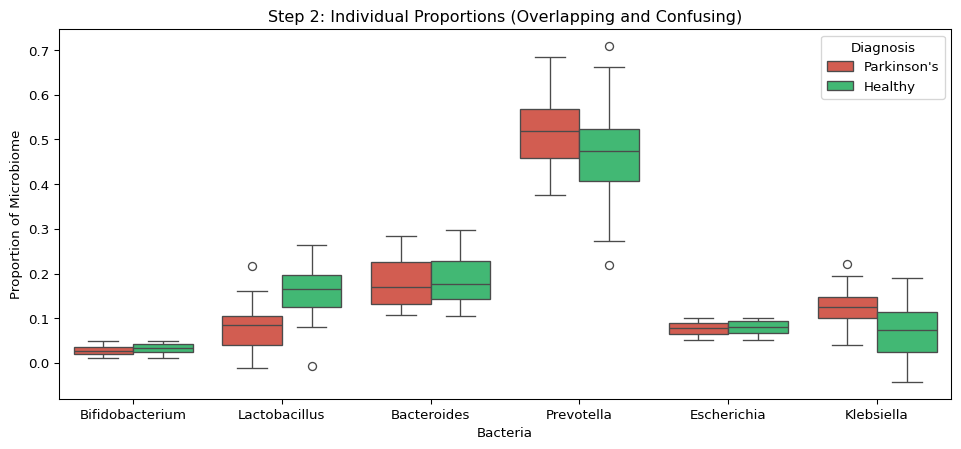

In [6]:
# Reshape and plot the proportion data
df_prop_melted = df_prop.melt(id_vars=["Diagnosis"], value_vars=cols, var_name="Bacteria", value_name="Proportion")

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_prop_melted, x="Bacteria", y="Proportion", hue="Diagnosis", palette=["#e74c3c", "#2ecc71"])
plt.title("Step 2: Individual Proportions (Overlapping and Confusing)")
plt.ylabel("Proportion of Microbiome")
plt.show()

Look closely at *Bifidobacterium* and *Lactobacillus* — the red and
green boxes practically sit on top of each other. If a patient showed up
with 10% *Bifidobacterium*, you’d be stuck: healthy people have that,
and so do sick people. One bacteria at a time, the signal is basically
invisible. Frustrating, right? Hang on — this is exactly where it gets
good.

### Step 3: Revealing the Hidden Pattern

Real biology is sneaky. Bacteria don’t live alone — they fight over food
and territory, so what really matters is often the *relationship
between* them, not any single one on its own. One bacteria can tell you
nothing, while two of them *together* can tell you everything.

Let’s test that idea. What if we stop staring at bacteria one at a time
and start adding them up in **pairs**?

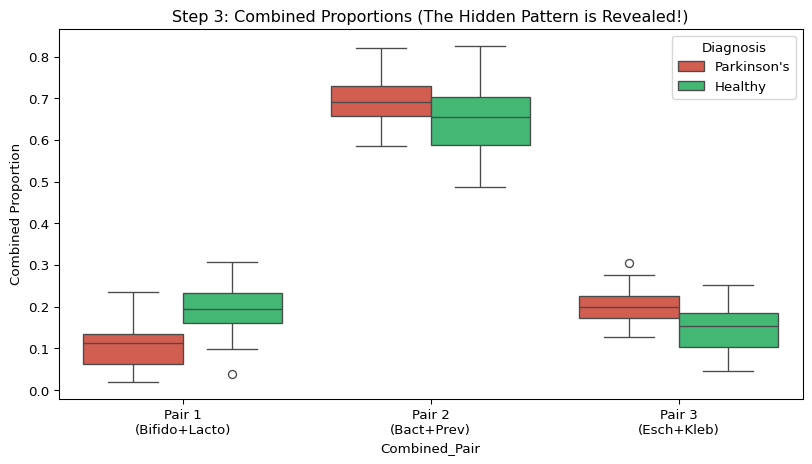

In [7]:
# Create 3 Combined Columns
df_prop["Pair1_Bifido_Lacto"] = df_prop["Bifidobacterium"] + df_prop["Lactobacillus"]
df_prop["Pair2_Bact_Prev"] = df_prop["Bacteroides"] + df_prop["Prevotella"]
df_prop["Pair3_Esch_Kleb"] = df_prop["Escherichia"] + df_prop["Klebsiella"]

comb_cols = ["Pair1_Bifido_Lacto", "Pair2_Bact_Prev", "Pair3_Esch_Kleb"]
df_comb_melted = df_prop.melt(id_vars=["Diagnosis"], value_vars=comb_cols, var_name="Combined_Pair", value_name="Proportion")

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_comb_melted, x="Combined_Pair", y="Proportion", hue="Diagnosis", palette=["#e74c3c", "#2ecc71"])
plt.title("Step 3: Combined Proportions (The Hidden Pattern is Revealed!)")
plt.ylabel("Combined Proportion")
# Make x-axis labels cleaner
plt.xticks(ticks=[0, 1, 2], labels=["Pair 1\n(Bifido+Lacto)", "Pair 2\n(Bact+Prev)", "Pair 3\n(Esch+Kleb)"])
plt.show()

Boom. Look at **Pair 1**: the red and green boxes suddenly pull apart —
Parkinson’s patients sit low, healthy patients sit high, with barely any
overlap. The signal was hiding in the *combination* the whole time.
Pairs 2 and 3? Still a jumbled mess — those are decoys we planted on
purpose. Figuring out which combinations carry the signal (and which are
traps) is the entire game.

## Predictive Modelling?

We got lucky above: with only 6 bacteria, we could hunt for the winning
pair by hand. But a real gut has *thousands* of bacterial families.
Nobody can eyeball a spreadsheet that wide and spot the magic
combinations — your brain would melt trying.

This is the moment **Machine Learning** kicks in. Instead of a human
guessing the rules, we hand the whole messy spreadsheet to a computer
and let it discover the pattern through trial and error: test, fail,
adjust, repeat, and slowly get smarter.

### Warm-Up: Teaching a Model to Draw the Line

Before we build a full brain-like network, let’s meet its simpler
cousin, **Logistic Regression**. It’s the perfect warm-up.

We already found that *Pair 1* (*Bifidobacterium* + *Lactobacillus*)
splits the groups nicely. Now we want to turn that split into an actual
*prediction*. Step one: swap the labels for numbers — **Healthy = 0**
and **Parkinson’s = 1**. Step two: ask the computer to draw one smooth
**S-shaped curve** that slides from 0 up to 1 and marks exactly where
the two groups divide.

Let’s fit it to all three pairs and see what pops out.

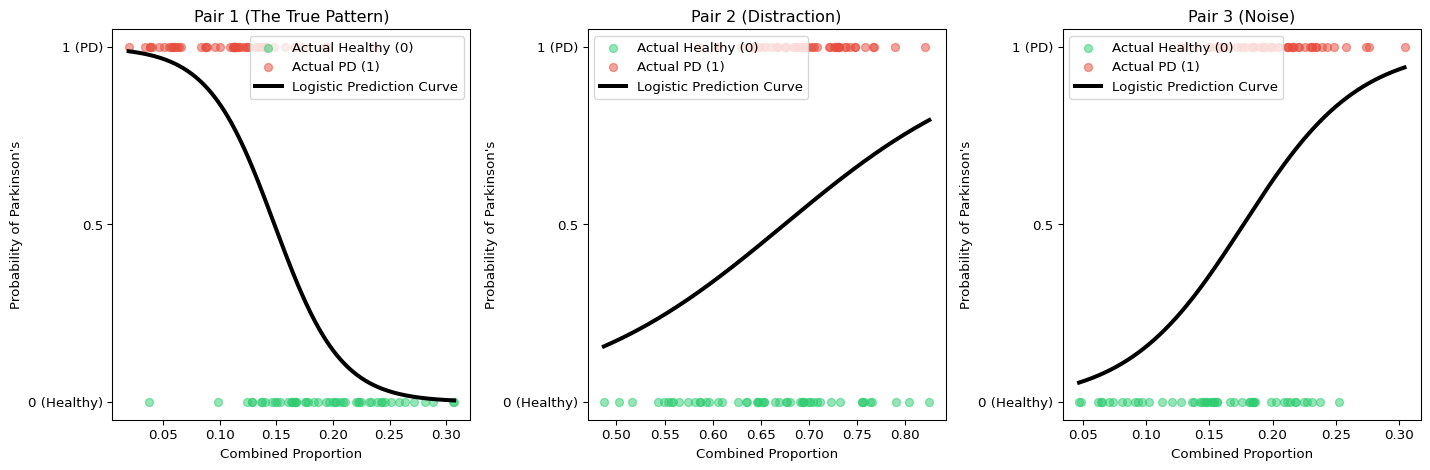

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

# Convert Diagnosis to numbers: Healthy = 0, Parkinson's = 1
y = (df_prop["Diagnosis"] == "Parkinson's").astype(int)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
axes = [ax1, ax2, ax3]
pairs = ["Pair1_Bifido_Lacto", "Pair2_Bact_Prev", "Pair3_Esch_Kleb"]
titles = ["Pair 1 (The True Pattern)", "Pair 2 (Distraction)", "Pair 3 (Noise)"]

for ax, pair, title in zip(axes, pairs, titles):
    X = df_prop[[pair]].values
    
    # Fit the Logistic Regression model
    # C=1000 removes the default penalty so we get a sharp S-curve
    model = LogisticRegression(C=1000)
    model.fit(X, y)
    
    # Create smooth line for the S-curve
    X_test = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    y_prob = model.predict_proba(X_test)[:, 1] # Probability of being PD (Class 1)
    
    # Scatter plot of actual patients
    ax.scatter(X[y==0], y[y==0], color='#2ecc71', label="Actual Healthy (0)", alpha=0.5)
    ax.scatter(X[y==1], y[y==1], color='#e74c3c', label="Actual PD (1)", alpha=0.5)
    
    # Plot the regression curve
    ax.plot(X_test, y_prob, color='black', linewidth=3, label="Logistic Prediction Curve")
    
    ax.set_title(title)
    ax.set_xlabel("Combined Proportion")
    ax.set_ylabel("Probability of Parkinson's")
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(['0 (Healthy)', '0.5', '1 (PD)'])
    ax.legend()

plt.tight_layout()
plt.show()

**Reading the charts:** that black S-curve is the model’s whole brain in
one line. In the first chart, a new patient with a Pair 1 value of 0.15
lands where the curve sits near **1** → the model calls it Parkinson’s.
A patient at 0.35 lands where the curve has dropped to **0** → Healthy.
It’s a genuine prediction machine.

Now check Pairs 2 and 3: the black line is nearly flat. That flatness is
the model shrugging: *“This tells me nothing — I can’t predict anything
from here.”* A flat curve is how the model calls out a decoy.

### The Mathematics Behind the S-Curve

Want the actual trick that bends a bacteria score into that smooth
curve? It’s one famous formula: the **Logistic Function** (a.k.a. the
*Sigmoid*). Don’t let the symbols scare you — we’re about to take it
apart piece by piece:

$$P(Y = 1 \mid z) = \frac{1}{1 + e^{-z}}$$

*(Curious how we typed these fancy equations? Crack open the raw `.qmd`
file for this project on GitHub and steal the code — that’s exactly what
it’s there for!)*

#### Breaking Down the Equation

Learn these pieces and you’ll be able to explain the whole thing in your
final report like a pro:

- **$P(Y = 1 \mid z)$**: reads as *“the chance the diagnosis ($Y$) is
  Parkinson’s ($1$), given the patient’s combined pattern score ($z$).”*
- **$e$**: Euler’s number, a famous constant roughly equal to $2.71828$
  — it’s math royalty, just like $\pi$ is roughly $3.14159$.
- **$z$**: the “secret recipe,” a single score the model cooks up for
  each patient. For our Pair 1 example, the computer builds it with a
  simple straight-line equation:

$$z = \beta_0 + \beta_1 \cdot (\text{Bifidobacterium} + \text{Lactobacillus})$$

#### How the Math Controls the Curve

The computer’s entire job while learning is to hunt down the two best
numbers: **$\beta_0$** (a baseline nudge) and **$\beta_1$** (how much
weight, or importance, to give the bacteria). Once it locks those in:

- Healthy gut → high combined proportion → $z$ is a big **positive**
  number. Plug a big positive into $\frac{1}{1 + e^{-z}}$ and the answer
  squishes down toward **$0$ (Healthy)**.
- Parkinson’s gut → low proportion → $z$ is a big **negative** number →
  the fraction flips and the answer climbs up toward **$1$
  (Parkinson’s)**.

As $z$ glides from negative to positive, the formula *automatically*
traces that perfect “S.” Nobody draws it by hand — the math does it for
you.

### Why We Need Neural Networks

Logistic Regression is slick, but did you catch the cheat? *We* were the
ones who combined *Bifidobacterium* and *Lactobacillus* into Pair 1. A
human did the detective work of finding the pattern first.

That’s fine with 6 bacteria. But a real gut has *thousands*
($x_1, x_2, x_3 \dots$), and nobody knows in advance which ones to add,
subtract, or mix together. We want the computer to discover the winning
combinations — let’s call them $z_1, z_2 \dots$ — completely on its own.

That’s the whole point of a **Neural Network**: instead of humans
guessing the recipes, we let the machine learn the functions
$z_j = f_j(x)$ by itself.

Think of a Neural Network like a detective agency with several floors
(called **Layers**):

1.  **The First Layer (Input, $x$):** Looks at the raw spreadsheet
    numbers for a patient (thousands of individual bacteria).
2.  **The Middle Layers (Hidden Layers, $z$):** Looks for hidden
    patterns. It automatically tests millions of combinations to create
    new features ($z_j$). It might figure out mathematically: *“Hey,
    whenever Bacteria A is high and Bacteria B is low, that’s a strong
    signal!”*
3.  **The Final Layer (Output, $y$):** Takes those hidden signals and
    draws a final logistic curve to make a guess: *“Based on these
    patterns, the probability is 85% that this person has Parkinson’s.”*

Here is a visual map of what that network looks like:

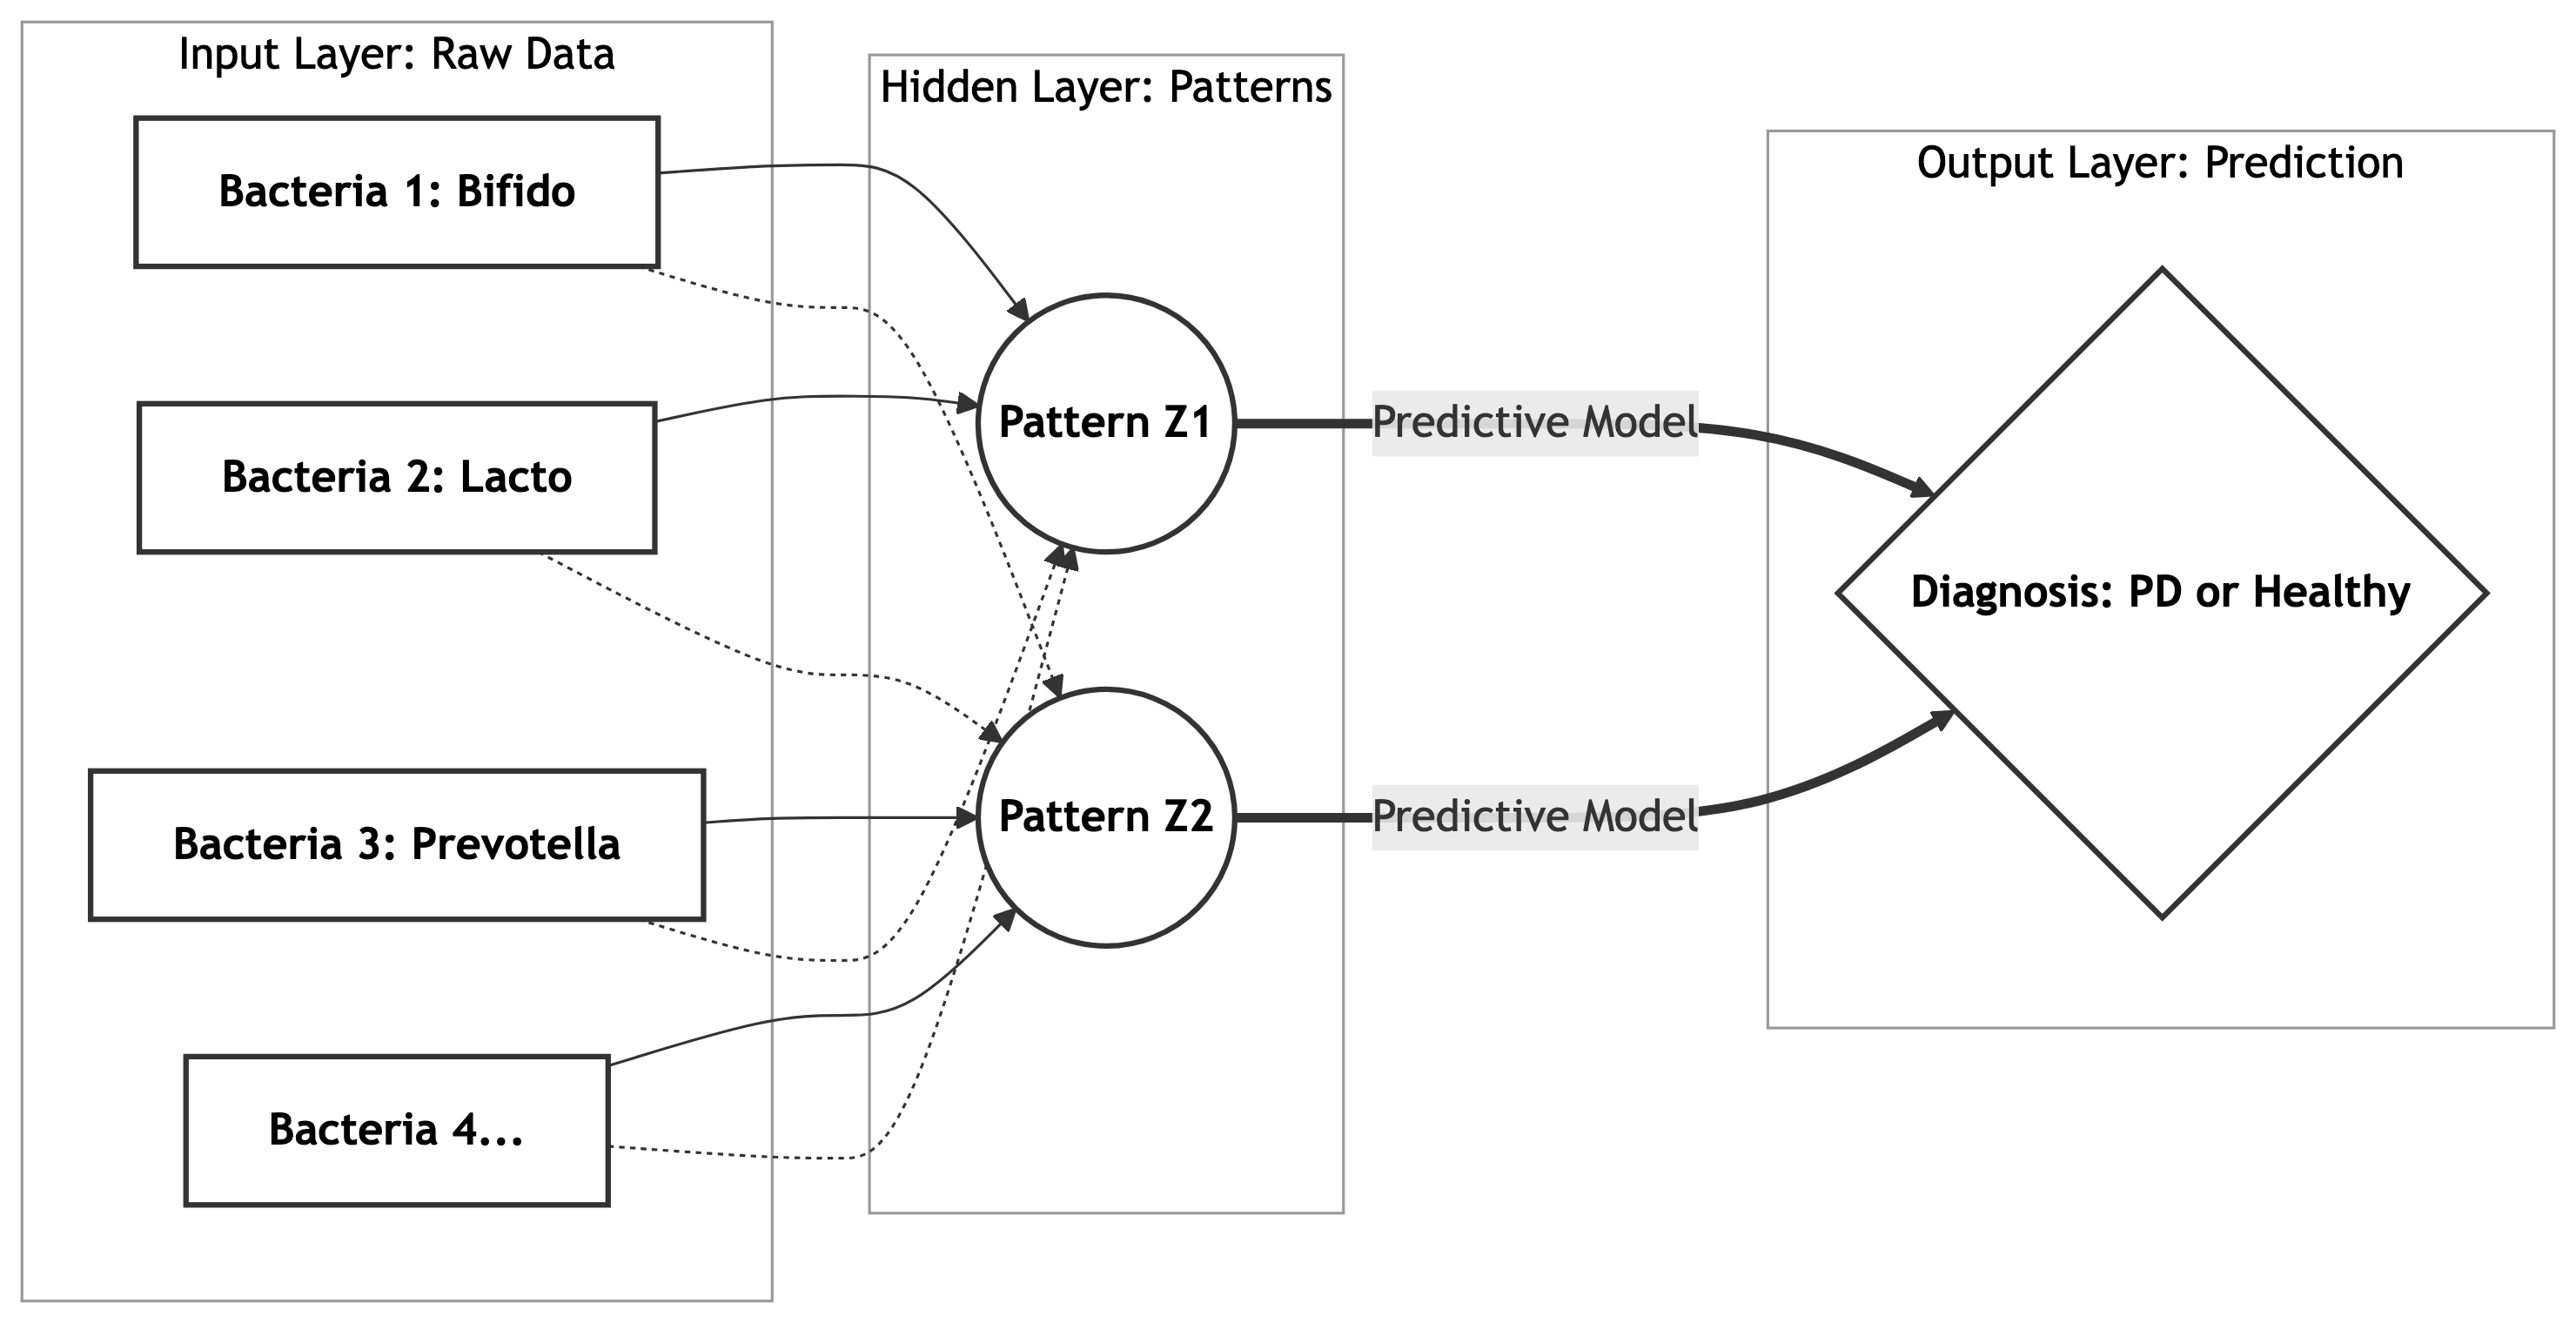

### So What Are These Hidden Patterns ($z$), Really?

Back in our Pair 1 example, we built the pattern the lazy way — just add
two bacteria together equally: $z = x_1 + x_2$.

A Neural Network is way craftier than that. It builds complex “recipes”
called **weighted sums**. It doesn’t just add; it *multiplies* some
bacteria up and *subtracts* others down to capture real biology:

- **Multiplication (Weights):** Not all bacteria matter equally. If
  *Bifidobacterium* is a massive health signal and *Lactobacillus* is
  only a minor one, the network multiplies them by different “weights”
  (importance scores).
  $$z_1 = 5.0 \cdot (\text{Bifido}) + 0.2 \cdot (\text{Lacto})$$
- **Subtraction (Negative Weights):** Bacteria are constantly at war in
  the gut. If a “bad” bacteria overgrows and wipes out the “good” ones,
  the network learns to penalize it with subtraction.
  $$z_2 = 2.0 \cdot (\text{Lacto}) - 4.5 \cdot (\text{Bad Pathogen})$$
  The network can whip up dozens of these $z$ formulas at once, mixing
  and matching all 3,000 bacteria with positive weights, negative
  weights, and fractions to map out the entire ecosystem of the gut!

**But how does it find the perfect weights for $z$?** We never type
those numbers in ourselves — that’s the whole magic. We feed the network
hundreds of patients whose answers we *already know*. It starts with
totally random weights, makes a guess, and checks how badly it missed.
Then it nudges its own internal math a hair (a $2.0$ becomes a $2.1$, a
plus flips to a minus) so the next guess lands a little closer. Repeat
that thousands of times and the network teaches *itself*. That whole
loop is called **training** the model — and soon you’ll be running it.

------------------------------------------------------------------------

## A Machine Learning Prodecure with Tensorflow

### Generating the Synthetic Cohort

Let’s fire up the data generator. We need patients, and since recruiting
100 actual humans and sequencing their gut microbiomes takes years of
effort and entirely too much grant funding, we will just conjure them
out of thin air using NumPy.

In [9]:
# Generate our two independent datasets (Training and Testing)
X_train, y_train = generate_microbiome_data(100,100)
X_test, y_test = generate_microbiome_data(100,100)

print("Data generated successfully!")
print(f"Training set: {X_train.shape[0]} patients")
print(f"Testing set: {X_test.shape[0]} patients")

Data generated successfully!
Training set: 200 patients
Testing set: 200 patients

### Training a Stripped-down Neural Network with Tensorflow

Time to unleash our neural network. For this round, we are intentionally
handicapping it by using a NN with very small number of neurons.

Let’s see if this stripped-down detective can solve the case. More
importantly, let’s strictly grade its final exam by expanding our
metrics to include **Precision** (how often it is right when it calls a
positive) and the **True Negative Rate / Specificity** (how well it
clears the truly healthy patients).

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import confusion_matrix
from IPython.display import display
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from itables import show

# --- 1. Build and Train the Baseline Neural Network ---
model = Sequential([
    # Explicit Input layer
    Input(shape=(6,)), 
    
    # Hidden Layer: 1 node using linear activation (Logistic Regression in disguise)
    Dense(2, activation='sigmoid'), 
    
    # Output Layer: 1 final decision maker
    Dense(1, activation='sigmoid') 
])

# Compile and train (using the RAW X_train data)
model.compile(optimizer=Adam(learning_rate=0.005), loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=200, verbose=0)
print("Model Training Complete!\n")

# --- 2. Make Predictions ---
# Predict using the RAW X_test data
pred_probs = model.predict(X_test, verbose=0).flatten()
y_hat = (pred_probs > 0.5).astype(int)

# --- 3. View Individual Patient Predictions ---
results_df = pd.DataFrame({
    'True Diagnosis (y)': y_test,
    'Predicted Probability': np.round(pred_probs, 3),
    'Model Guess (y_hat)': y_hat
})

print("The Final Exam: Individual Patient Predictions")
show(results_df, classes="display compact", style="width:100%;", scrollX=True, lengthMenu=[5, 10])

# --- 4. Calculate and Display Metrics ---
# Extract counts
tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()

# Calculate expanded metrics
error_rate = (fp + fn) / len(y_test)
fpr = fp / (tn + fp)
recall = tp / (tp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
tnr = tn / (tn + fp) # True Negative Rate (Specificity)

# Calculate Negative Predictive Value (NPV) to perfectly balance the table
npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0

# Build a textbook-style balanced Confusion Matrix
cm_df = pd.DataFrame({
    "Predicted Healthy": [
        f"TN = {tn}", 
        f"FN = {fn}", 
        f"NPV: {npv:.2%}"
    ],
    "Predicted Parkinson's": [
        f"FP = {fp}", 
        f"TP = {tp}", 
        f"Precision: {precision:.2%}"
    ],
    "Row Marginals": [
        f"TNR (Specificity): {tnr:.2%}", 
        f"Recall (Sensitivity): {recall:.2%}", 
        f"Overall Error Rate: {error_rate:.2%}"
    ]
}, index=["Actual Healthy", "Actual Parkinson's", "Column Marginals"])

# Display as a clean HTML table
print("\nGrading the Exam: Model Metrics Summary")
display(cm_df)

Model Training Complete!

The Final Exam: Individual Patient Predictions

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)



Grading the Exam: Model Metrics Summary

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


### Peeking Inside the Black Box

Accuracy metrics are great, but in this class, we do not blindly trust a
black box. Let’s rip the learned weights right out of the model’s brain
and draw the exact connections it relied on.

If our model fell for the compositional data trap (which, spoiler alert,
it almost certainly did), this dynamic graph is going to expose the
crime immediately.

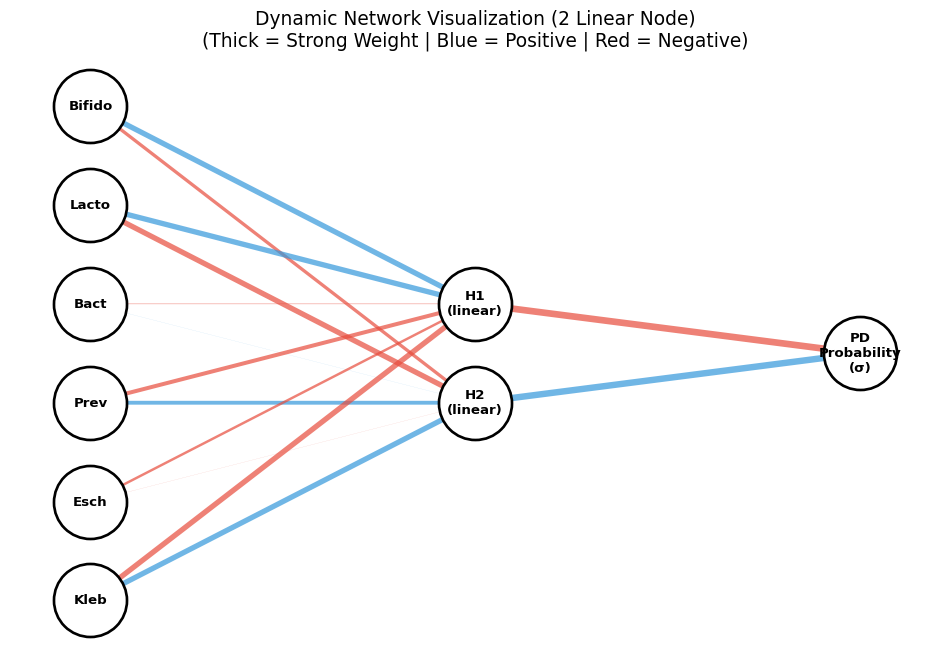

In [11]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# 1. Extract weights directly from the model
hidden_weights = model.layers[0].get_weights()[0] 
output_weights = model.layers[1].get_weights()[0] 

# Dynamically count the nodes based on the weight matrices
n_inputs = hidden_weights.shape[0]
n_hidden = hidden_weights.shape[1]
n_outputs = output_weights.shape[1]

# 2. Setup the Graph and dynamically generate node names with the Sigmoid symbol
G = nx.DiGraph()
inputs = ["Bifido", "Lacto", "Bact", "Prev", "Esch", "Kleb"] 
# Append the Greek letter Sigma (σ) to indicate the non-linear activation (if applicable)
hidden = [f"H{i+1}\n(linear)" for i in range(n_hidden)] # Updated to reflect your linear layer!
outputs = ["PD\nProbability\n(σ)"]

pos = {} 

# Helper function to center nodes vertically
def get_y_positions(n_nodes):
    return np.linspace(n_nodes - 1, 0, n_nodes) - (n_nodes - 1) / 2

# Place Input Nodes (x=0)
y_inputs = get_y_positions(n_inputs)
for i, name in enumerate(inputs):
    G.add_node(name)
    pos[name] = (0, y_inputs[i])

# Place Hidden Nodes (x=1)
y_hidden = get_y_positions(n_hidden)
for i, name in enumerate(hidden):
    G.add_node(name)
    pos[name] = (1, y_hidden[i])

# Place Output Node (x=2)
for i, name in enumerate(outputs):
    G.add_node(name)
    pos[name] = (2, 0) 

# 3. Create the Edges (Lines) based on the weights
edges = []
colors = []
thickness = []

for i, in_node in enumerate(inputs):
    for j, h_node in enumerate(hidden):
        weight = hidden_weights[i, j]
        G.add_edge(in_node, h_node)
        edges.append((in_node, h_node))
        colors.append('#3498db' if weight > 0 else '#e74c3c') 
        thickness.append(min(abs(weight) * 2, 4)) 

for i, h_node in enumerate(hidden):
    for j, out_node in enumerate(outputs):
        weight = output_weights[i, j]
        G.add_edge(h_node, out_node)
        edges.append((h_node, out_node))
        colors.append('#3498db' if weight > 0 else '#e74c3c')
        thickness.append(min(abs(weight) * 2, 5))

# 4. Draw the Graph
plt.figure(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='white', edgecolors='black', linewidths=2)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=colors, width=thickness, arrowsize=12, alpha=0.7)

plt.title(f"Dynamic Network Visualization ({n_hidden} Linear Node)\n(Thick = Strong Weight | Blue = Positive | Red = Negative)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

------------------------------------------------------------------------

## Collection of Microbiome Data Related To Parkinson

Turning raw DNA sequences into a clean spreadsheet is genuinely tedious
work — so we’ve already handled the messy part for you.

- **Core Dataset:** A preprocessed dataset is ready to go in the
  `datasets` directory of this GitHub repository: [PDNN GitHub
  Repo](https://github.com/longhaiSK/PDNN).

- **Data Collection Task (Student A):** One team member should take the
  lead on tracking down extra data to test the model on. Follow the
  exact steps in this [Google Colab Data
  Notebook](https://colab.research.google.com/drive/170dd6Qv-IgYyj4_WxvSOlmS8N5wtNGgo#scrollTo=3V9zVKkpWlQe).
  More instructions live in the repository’s “More Datasets” directory.

------------------------------------------------------------------------

## The Lab Bench: Computing in Google Colab

You’ll build your Neural Network with a tool called **TensorFlow**,
running inside **Google Colab** — a free coding lab that lives right in
your web browser. Nothing to install, and no fancy computer required.

### Setting Up Colab

1.  Go to [Google Colab](https://colab.research.google.com/) and create
    a new notebook.
2.  Make your code run way faster by switching on the GPU: `Runtime` \>
    `Change runtime type` \> pick `GPU` under Hardware accelerator.

> **Essential Tutorials & Resources**
>
> Never used Colab or coded a Neural Network before? Don’t panic — the
> internet is packed with awesome, interactive guides. We highly
> recommend clicking through these before you start writing your own
> code:
>
> **Getting to Know Google Colab:**
>
> - [Welcome to
>   Colaboratory](https://colab.research.google.com/notebooks/intro.ipynb):
>   The official quick-start guide to how text and code blocks work
>   together in a notebook.
> - [Markdown Guide for
>   Colab](https://colab.research.google.com/notebooks/markdown_guide.ipynb):
>   Learn how to format your text, add headers, and make your notebook
>   look like a real scientific report.
>
> **Learning TensorFlow & Deep Learning:**
>
> - [TensorFlow 2 Quickstart for
>   Beginners](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb):
>   The classic “Hello World” of Deep Learning.
> - [Basic Classification with
>   Keras](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/keras/classification.ipynb):
>   A fantastic intro to building layers, training a model, and making
>   predictions.
> - [Classify Structured
>   Data](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/structured_data/preprocessing_layers.ipynb):
>   *Highly recommended!* This one shows you how to train a network on a
>   plain spreadsheet (CSV data) — exactly the kind of data you’ll be
>   using for the microbiome project!
>
> **Conceptual Deep-Dive:** \* [Google’s Machine Learning Crash
> Course](https://developers.google.com/machine-learning/crash-course):
> Want to go deeper into the math and theory behind the code? This free
> course is the gold standard.

------------------------------------------------------------------------

## The Publishing Press: Rendering Your PDF Inside Colab

You don’t need to leave Google Colab to create your final PDF. You can
tell Colab’s servers to install Quarto, read your notebook, and generate
the final manuscript right in the cloud.

### Step 1: Add Your Header

At the very top of your Colab notebook, create a new **Text** cell. It
must be the very first block in your document. Add your “YAML
Header”—the instructions for how the PDF should look:

``` yaml
---
title: "Predicting Parkinson's Disease from Gut Microbiome Data"
author: "Your Name"
format:
  pdf:
    pdf-engine: typst
---
```

### Step 2: Write Your Report

Use standard Colab **Text** cells between your Python code blocks to
write your actual report. Explain the biology, describe what your neural
network is doing, and analyze the results.

### Step 3: Install Quarto on Colab

When your code is running perfectly and your writing is finished, scroll
to the very bottom of your notebook and create a new **Code** cell.
Paste the following commands to install Quarto onto Colab’s temporary
server:

``` bash
!wget -q https://github.com/quarto-dev/quarto-cli/releases/download/v1.4.553/quarto-1.4.553-linux-amd64.deb
!dpkg -i quarto-1.4.553-linux-amd64.deb
```

*(Run the cell. It will take a few seconds to install).*

### Step 4: Render the PDF

Create another **Code** cell at the bottom. We need to tell Quarto to
take your current notebook (which Colab usually saves temporarily as a
file in its background folders) and render it into a PDF:

``` bash
# This saves the current state of your notebook
from IPython.display import display, Javascript
display(Javascript('IPython.notebook.save_checkpoint();'))

# This tells Quarto to render the default Colab notebook file
!quarto render /content/drive/MyDrive/Colab\ Notebooks/Your_Notebook_Name.ipynb --to pdf
```

*(Make sure to change `Your_Notebook_Name` to whatever you actually
named your file in Google Drive!)*

### Step 5: Download the Result

Once the rendering cell finishes running, click the **Folder icon** on
the far left menu of your Colab screen. You will see a list of files.
Find your newly generated PDF, click the three dots next to it, and
select **Download**.

You now have a polished, competition-ready manuscript without ever
leaving your browser!

------------------------------------------------------------------------

## Plans and Goals

To ensure this summer research project is both manageable and highly
competitive for the upcoming science fair season, the work is divided
into four distinct phases. Each phase builds a core competency in data
science and computational biology, leading to a complete, reproducible
scientific manuscript.

### Data Collection and Microbiome Pipeline

- **The Mission:** Access and clean public gut microbiome datasets
  containing taxonomic profiles of individuals with and without
  Parkinson’s Disease (PD).
- **The Action:** Follow the provided Google Colab framework to process
  the raw abundance tables. You will handle tasks like normalizing data,
  filtering out low-abundance features, and ensuring taxonomic columns
  (such as unassigned operational taxonomic units) are properly
  structured for machine learning.

### Neural Network Development and Optimization

- **The Mission:** Build and train a custom neural network architecture
  capable of detecting subtle bacterial signatures associated with PD.
- **The Action:** Program a multi-layer perceptron (MLP) in Python using
  PyTorch or TensorFlow. You will optimize the network’s predictive
  accuracy by adjusting parameters, evaluating performance metrics like
  AUC-ROC (Area Under the Receiver Operating Characteristic curve), and
  using cross-validation to prevent overfitting.

### Reproducible Reporting with Quarto

- **The Mission:** Move beyond messy code notebooks and compile the
  entire project into a professional, reproducible scientific document.
- **The Action:** Develop a dynamic Quarto document (`.qmd`) using a
  clean typesetting template. This document will seamlessly integrate
  your explanatory text, background biology, live Python code blocks,
  and automatically generated evaluation graphics into a cohesive report
  fit for judges.

### Competition Strategy and Registration

- **The Mission:** Share your breakthroughs with the scientific
  community by entering provincial and national youth science
  competitions.
- **The Action:** Use the finalized Quarto manuscript to prepare
  submissions for targeted data and biotechnology fairs:
- **STEM Fellowship Big Data Challenge:** Prepare a digital poster and
  data-centric report tailored to this open-source AI challenge. Learn
  more and register at
  [stemfellowship.org/programs/hsbdc](https://www.stemfellowship.org/programs/hsbdc).
- **Sanofi Biogenius Canada:** Submit a formal biotech-focused project
  proposal to enter the regional competition track. You can read up on
  their project requirements and application process at
  [biogenius.ca](https://biogenius.ca/).
- **Canada-Wide Science Fair (CWSF) & Regional Qualifying:** To reach
  the national stage, you must first compete and qualify locally. You
  can enter the [Saskatoon Regional Science
  Fair](https://region.youthscience.ca/saskatoon/) which normally takes
  place in late March or early April, and acts as the stepping stone to
  the national [Youth Science Canada](https://youthscience.ca/)
  competition.

------------------------------------------------------------------------

## Appendix: Starter Template for Your Report

Copy everything inside the box below, switch Posit Cloud to **Source**
mode, paste it in, then flip back to **Visual** mode and start writing!

``` markdown
---
title: "Predicting Parkinson's Disease from Gut Microbiome Data"
author: "Your Names Here"
format: html
---

## Introduction
<!-- Write 2-3 sentences explaining what Parkinson's Disease is and why the bacteria in our gut might act as a clue to diagnosing it. -->

## The Dataset
<!-- Explain where the data came from. Insert a small table here showing how many patients vs. healthy controls are in our spreadsheet. -->

## Our Neural Network Model
<!-- Insert an image of your model architecture or summary here. Explain how many layers you chose for your "detective agency" and why. -->

## Results
<!-- Insert your accuracy charts here. Remember to use the What, So What, Now What framework to explain them! -->

## Conclusion
<!-- Did the model successfully predict PD? What was the hardest part of building it, and what would you try next time? -->
```

Abbott, Robert D., Helen Petrovitch, Lon R. White, et al. 2001.
“Frequency of Bowel Movements and the Future Risk of
<span class="nocase">Parkinson’s</span> Disease.” *Neurology* 57 (3):
456–62. <https://doi.org/10.1212/WNL.57.3.456>.

Braak, Heiko, Udo Rüb, W. P. Gai, and Kelly Del Tredici. 2003.
“Idiopathic <span class="nocase">Parkinson’s</span> Disease: Possible
Routes by Which Vulnerable Neuronal Types May Be Subject to
Neuroinvasion by an Unknown Pathogen.” *Journal of Neural Transmission*
110 (5): 517–36.

Fasano, Alberto, Naomi P. Visanji, Louis W. C. Liu, Anthony E. Lang, and
Ronald F. Pfeiffer. 2015. “Gastrointestinal Dysfunction in
<span class="nocase">Parkinson’s</span> Disease.” *The Lancet Neurology*
14 (6): 625–39.

Liu, Bojing, Fang Fang, Nancy L. Pedersen, et al. 2017. “Vagotomy and
Parkinson Disease: A Swedish Register-Based Matched-Cohort Study.”
*Neurology* 88 (21): 1996–2002.
<https://doi.org/10.1212/WNL.0000000000003961>.

Maini Rekdal, Vayu, Elizabeth N. Bess, Jordan E. Bisanz, Peter J.
Turnbaugh, and Emily P. Balskus. 2019. “Discovery and Inhibition of an
Interspecies Gut Bacterial Pathway for Levodopa Metabolism.” *Science*
364 (6445): eaau6323. <https://doi.org/10.1126/science.aau6323>.

Sampson, Timothy R., Justine W. Debelius, Taren Thron, et al. 2016. “Gut
Microbiota Regulate Motor Deficits and Neuroinflammation in a Model of
<span class="nocase">Parkinson’s</span> Disease.” *Cell* 167 (6):
1469–80. <https://doi.org/10.1016/j.cell.2016.11.018>.

Scheperjans, Filip, Velma Aho, Pedro A. B. Pereira, et al. 2015. “Gut
Microbiota Are Related to <span class="nocase">Parkinson’s</span>
Disease and Clinical Phenotype.” *Movement Disorders* 30 (3): 350–58.

Svensson, Elisabeth, Erzsébet Horváth-Puhó, Reimar W. Thomsen, et al.
2015. “Vagotomy and Subsequent Risk of
<span class="nocase">Parkinson’s</span> Disease.” *Annals of Neurology*
78 (4): 522–29. <https://doi.org/10.1002/ana.24448>.